In [1]:
from pathlib import Path

import numpy as onp
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
BASERESULTSDIR = Path("example_results/")
QUANTITY = "forces"

In [3]:
ROOTNAMES_TO_LEGEND_LABELS = {
    "msm_rcut-3.0_p-4": "$r_{\mathrm{cut}} = 3 \overline{d}$, $p=4$",
    "msm_rcut-6.0_p-6": "$r_{\mathrm{cut}} = 6 \overline{d}$, $p=6$",
    "exact": "exact",
}

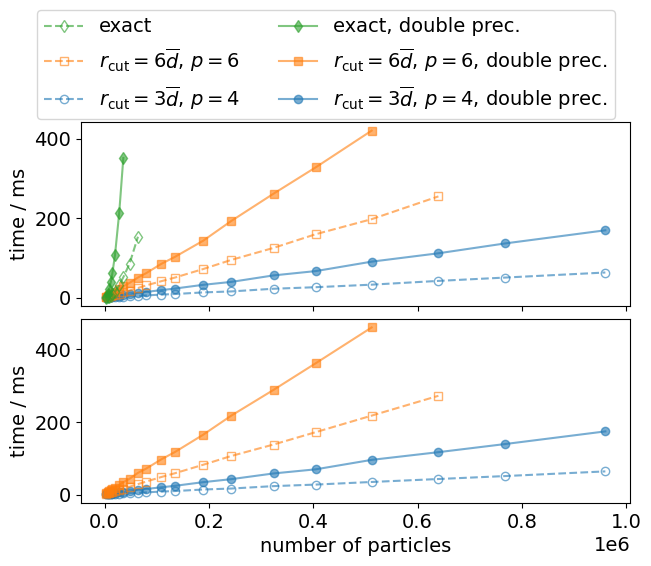

In [37]:
MARKERLIST = ["o", "s", "d"]
plt.rcParams["font.size"] = 14  # TODO

fig, axs = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(6.4, 5.6),
    layout="constrained",
)
axs[-1].set_xlabel("number of particles")
for ax, pbclabel in zip(axs, ["nonperiodic", "periodic"]):
    # ax.set_title(pbclabel)    # TODO
    ax.set_ylabel("time / ms")
    for rootname, marker in zip(ROOTNAMES_TO_LEGEND_LABELS, MARKERLIST):
        if pbclabel == "periodic" and rootname == "exact":
            # Cannot compute an exact all-pairs reference result in periodic case
            continue
        resultsdirname = pbclabel + "-" + rootname
        label = ROOTNAMES_TO_LEGEND_LABELS[rootname]
        for double_precision, linestyle, facecolor in zip(
            [False, True], ["--", "-"], ["none", None]
        ):
            color = None
            if double_precision:
                resultsdirname += "_doubleprec"
                label += ", double prec."
                color = lns[0].get_color()
            resultsdir = BASERESULTSDIR / resultsdirname
            results = pd.read_csv(resultsdir / "results.csv")
            particle_numbers = results["n_particles"].values
            times = results["time"].values
            lns = ax.plot(
                particle_numbers,
                1e3 * times,
                label=label,
                alpha=0.6,
                color=color,
                marker=marker,
                markerfacecolor=facecolor,
                linestyle=linestyle,
            )

# Reorder legend entries such that the single- and double-precision versions
# of the same algorithm/settings are next to each other on the same line:
reordered_lines = axs[0].get_lines()[1::2] + axs[0].get_lines()[::2]
fig.legend(
    ncols=2,
    handles=reordered_lines,
    reverse=True,
    loc="outside upper center",
)

plt.show()

# TODO: title the subplots with periodic/nonperiodic?

# Save plots in logarithmic scale
for ax in axs:
    ax.set_xscale("log")
    ax.set_yscale("log")
filename_without_suffix = f"scaling_{QUANTITY}" + "_loglog"
for suffix in [".png", ".pdf"]:
    fig.savefig(BASERESULTSDIR / (filename_without_suffix + suffix))

# Save plots in linear scale
for ax in axs:
    ax.set_xscale("linear")
    ax.set_yscale("linear")
    ax.set_xlim(left=0.0)
    ax.set_ylim(bottom=0.0)
ax = axs[-1]
original_xlim = ax.get_xlim()
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([str(lbl) for lbl in ax.get_xticks() / 10**6])
ax.set_xlim(original_xlim)
ax.set_xlabel("number of particles / $10^6$")
filename_without_suffix = f"scaling_{QUANTITY}"
for suffix in [".png", ".pdf"]:
    fig.savefig(BASERESULTSDIR / (filename_without_suffix + suffix))

plt.show()